# CLASP terms on DBAASP (`all_in`)

Filter `results/data/all_in/peptides_apex.csv` to DBAASP sequences, reuse the
stored APEX MIC for *S. aureus* ATCC 12600, and score the product-variant
MEROPS cleavage term Φ<sub>cleav</sub>.

- Descriptive statistics: **cleavage term** Φ<sub>cleav</sub> only
- Histogram of Φ<sub>cleav</sub>
- Scatter: log<sub>2</sub> MIC vs Φ<sub>cleav</sub>
- Overlaid histograms of the CLASP potential
  `log2_mic + λ · Φ_cleav` for λ ∈ {0.1, 0.5, 0.9}
- Literature stable/labile *S. aureus* protease controls on the DBAASP Φ distribution

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

cwd = Path.cwd().resolve()
project_root = next(
    (p for p in [cwd, *cwd.parents] if (p / "src" / "pep_compass").is_dir()),
    cwd,
)
sys.path.insert(0, str(project_root / "src"))

ALL_IN_CSV = project_root / "results" / "data" / "all_in" / "peptides_apex.csv"
OUT_DIR = project_root / "results" / "clasp_dbaasp_inspection"
OUT_DIR.mkdir(parents=True, exist_ok=True)

MIC_COLUMN = "S. aureus ATCC 12600"
APEX_INDEX = 7          # same strain as MIC_COLUMN / MEROPS dataset 7
MEROPS_DATASETS = (7,)
VARIANT = "product"
LAMBDAS = (0.1, 0.5, 0.9)
DEVICE = "cpu"

print("project_root:", project_root)
print("all_in csv:", ALL_IN_CSV, "exists=", ALL_IN_CSV.exists())

project_root: C:\Users\Karol\Desktop\PepCompass\pep-compass
all_in csv: C:\Users\Karol\Desktop\PepCompass\pep-compass\results\data\all_in\peptides_apex.csv exists= True


In [2]:
from pep_compass.optimization.components.helpers.proteolysis import (
    CleavagePotential,
    load_protease_panel,
)

raw = pd.read_csv(ALL_IN_CSV, usecols=["sequence", "dataset", MIC_COLUMN])
dbaasp = (
    raw[raw["dataset"].str.contains("dbaasp", case=False, na=False)]
    .drop_duplicates(subset=["sequence"])
    .reset_index(drop=True)
)
dbaasp["length"] = dbaasp["sequence"].str.len()
dbaasp["mic_uM"] = dbaasp[MIC_COLUMN].astype(float)
dbaasp["log2_mic"] = np.log2(dbaasp["mic_uM"])

print(f"DBAASP peptides: {len(dbaasp)} (unique sequences)")
print(dbaasp["length"].describe().round(2))

DBAASP peptides: 3038 (unique sequences)
count    3038.00
mean       16.86
std         4.35
min        10.00
25%        13.00
50%        17.00
75%        20.00
max        25.00
Name: length, dtype: float64


In [3]:
panel = load_protease_panel(MEROPS_DATASETS, device=DEVICE)
cleavage = CleavagePotential(panel, variant=VARIANT, device=DEVICE)
phi = (
    cleavage.sequence_log_potential(dbaasp["sequence"].tolist())
    .detach()
    .cpu()
    .numpy()
)
dbaasp["cleavage"] = phi.astype(float)          # Φ_cleav (product)
# cleavage_term at the default λ=0.1 used in CLASP; proportional for other λ
dbaasp["cleavage_term"] = 0.1 * dbaasp["cleavage"]

for lam in LAMBDAS:
    dbaasp[f"potential_lam_{lam}"] = dbaasp["log2_mic"] + lam * dbaasp["cleavage"]

out_csv = OUT_DIR / "dbaasp_clasp_components.csv"
dbaasp.to_csv(out_csv, index=False)
print("wrote", out_csv)
dbaasp[["sequence", "log2_mic", "cleavage", "cleavage_term"]].head()

wrote C:\Users\Karol\Desktop\PepCompass\pep-compass\results\clasp_dbaasp_inspection\dbaasp_clasp_components.csv


,sequence,log2_mic,cleavage,cleavage_term
0,AAARLRLLLYLITRR,5.557998,-16.037914,-1.603791
1,AAHCIALRKGYK,6.501487,-17.312645,-1.731264
2,AAHCIQLGKR,7.060378,-17.435198,-1.743520
3,AAHCIVLHHN,7.113450,-17.782173,-1.778217
4,AAHCLAIGRK,6.888802,-17.386063,-1.738606


## Descriptive statistics — cleavage term Φ<sub>cleav</sub>

Median, all deciles (P10…P90), quartiles, mean, variance / std, IQR, range,
and skewness / kurtosis of the product-variant cleavage potential.

In [4]:
x = dbaasp["cleavage"].to_numpy()
deciles = {f"p{p}": float(np.percentile(x, p)) for p in range(10, 100, 10)}
stats = {
    "n": int(x.size),
    "mean": float(np.mean(x)),
    "median": float(np.median(x)),
    "std": float(np.std(x, ddof=1)),
    "variance": float(np.var(x, ddof=1)),
    "mad": float(np.median(np.abs(x - np.median(x)))),
    "iqr": float(np.percentile(x, 75) - np.percentile(x, 25)),
    "min": float(np.min(x)),
    "max": float(np.max(x)),
    "range": float(np.max(x) - np.min(x)),
    "q1": float(np.percentile(x, 25)),
    "q3": float(np.percentile(x, 75)),
    **deciles,
    "skewness": float(pd.Series(x).skew()),
    "kurtosis_excess": float(pd.Series(x).kurtosis()),
}
stats_df = pd.DataFrame({"metric": list(stats.keys()), "value": list(stats.values())})
stats_path = OUT_DIR / "cleavage_descriptive_stats.csv"
stats_df.to_csv(stats_path, index=False)
print(stats_df.to_string(index=False))
print("wrote", stats_path)

         metric       value
              n 3038.000000
           mean  -16.758027
         median  -16.695888
            std    0.699437
       variance    0.489212
            mad    0.470222
            iqr    0.959589
            min  -18.402334
            max  -11.528978
          range    6.873356
             q1  -17.257730
             q3  -16.298141
            p10  -17.694561
            p20  -17.398029
            p30  -17.143238
            p40  -16.909218
            p50  -16.695888
            p60  -16.518554
            p70  -16.380482
            p80  -16.203536
            p90  -15.991336
       skewness    0.440787
kurtosis_excess    2.236008
wrote C:\Users\Karol\Desktop\PepCompass\pep-compass\results\clasp_dbaasp_inspection\cleavage_descriptive_stats.csv


## Histogram of Φ<sub>cleav</sub>

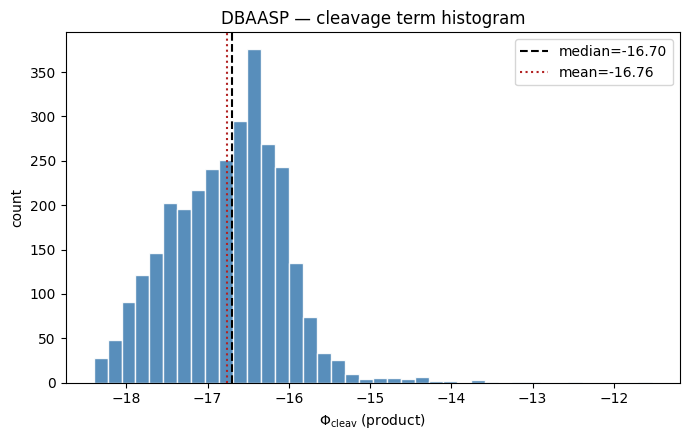

In [5]:
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.hist(dbaasp["cleavage"], bins=40, color="steelblue", edgecolor="white", alpha=0.9)
ax.axvline(stats["median"], color="black", ls="--", lw=1.5, label=f"median={stats['median']:.2f}")
ax.axvline(stats["mean"], color="firebrick", ls=":", lw=1.5, label=f"mean={stats['mean']:.2f}")
ax.set_xlabel(r"$\Phi_{\mathrm{cleav}}$ (product)")
ax.set_ylabel("count")
ax.set_title("DBAASP — cleavage term histogram")
ax.legend()
fig.tight_layout()
fig.savefig(OUT_DIR / "cleavage_histogram.png", dpi=150)
plt.show()

## Scatter: log<sub>2</sub> MIC vs cleavage term

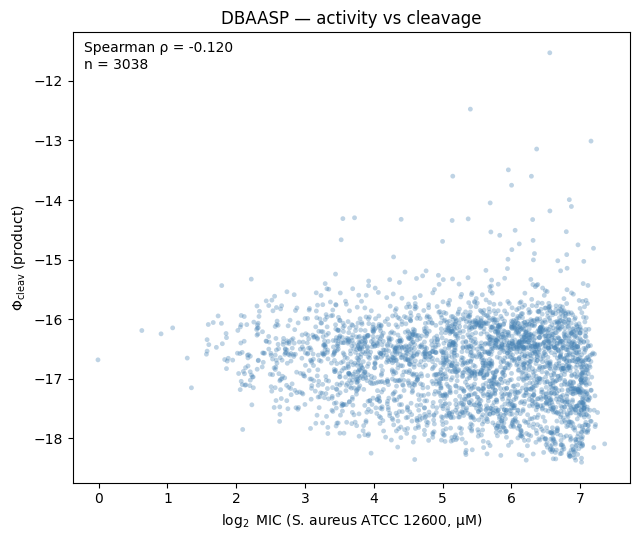

In [6]:
fig, ax = plt.subplots(figsize=(6.5, 5.5))
ax.scatter(
    dbaasp["log2_mic"],
    dbaasp["cleavage"],
    s=12,
    alpha=0.35,
    c="steelblue",
    edgecolors="none",
)
ax.set_xlabel(r"$\log_2$ MIC (S. aureus ATCC 12600, µM)")
ax.set_ylabel(r"$\Phi_{\mathrm{cleav}}$ (product)")
ax.set_title("DBAASP — activity vs cleavage")
rho = dbaasp["log2_mic"].corr(dbaasp["cleavage"], method="spearman")
ax.text(
    0.02,
    0.98,
    f"Spearman ρ = {rho:.3f}\nn = {len(dbaasp)}",
    transform=ax.transAxes,
    va="top",
    fontsize=10,
)
fig.tight_layout()
fig.savefig(OUT_DIR / "log2mic_vs_cleavage_scatter.png", dpi=150)
plt.show()

## Potential histograms for λ ∈ {0.1, 0.5, 0.9}

Potential minimized by the CLASP black box:
`potential(λ) = log2_mic + λ · Φ_cleav`.

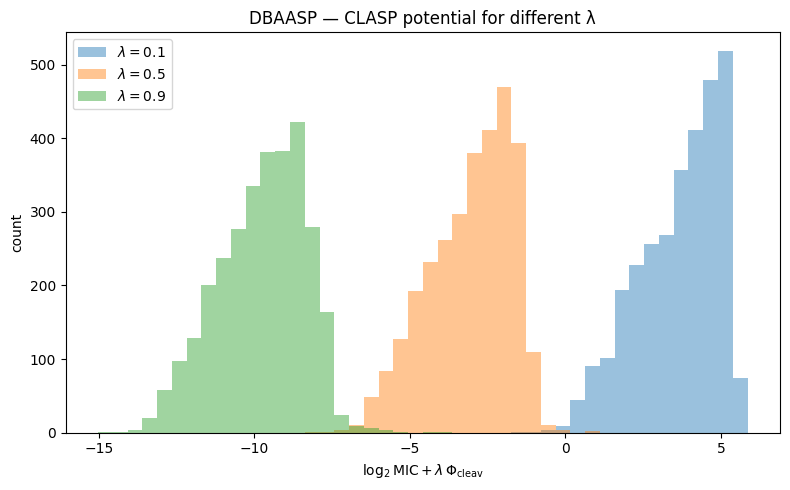

In [7]:
fig, ax = plt.subplots(figsize=(8, 5))
colors = {0.1: "#1f77b4", 0.5: "#ff7f0e", 0.9: "#2ca02c"}
# Shared bin edges so overlays are comparable
all_vals = np.concatenate([dbaasp[f"potential_lam_{lam}"].to_numpy() for lam in LAMBDAS])
bins = np.linspace(all_vals.min(), all_vals.max(), 45)
for lam in LAMBDAS:
    ax.hist(
        dbaasp[f"potential_lam_{lam}"],
        bins=bins,
        alpha=0.45,
        color=colors[lam],
        label=fr"$\lambda={lam}$",
        edgecolor="none",
    )
ax.set_xlabel(r"$\log_2\mathrm{MIC} + \lambda\,\Phi_{\mathrm{cleav}}$")
ax.set_ylabel("count")
ax.set_title("DBAASP — CLASP potential for different λ")
ax.legend()
fig.tight_layout()
fig.savefig(OUT_DIR / "potential_histograms_by_lambda.png", dpi=150)
plt.show()

In [8]:
print("Outputs in", OUT_DIR)
for path in sorted(OUT_DIR.iterdir()):
    print(" -", path.name)

Outputs in C:\Users\Karol\Desktop\PepCompass\pep-compass\results\clasp_dbaasp_inspection
 - cleavage_controls_on_dbaasp.png
 - cleavage_descriptive_stats.csv
 - cleavage_histogram.png
 - dbaasp_clasp_components.csv
 - log2mic_vs_cleavage_scatter.png
 - potential_histograms_by_lambda.png
 - stability_controls_cleavage.csv


## Literature controls (S. aureus protease stability)

Score known **stable** vs **labile** peptides with the same product Φ<sub>cleav</sub> and place them on the DBAASP distribution.

| Role | Name | Sequence | Note |
|---|---|---|---|
| stable | cateslytin (bCTL) | `RSMRLSFRARGYGFR` | Resistant to *S. aureus* supernatants |
| stable | RRP9W4 | `RRPRPRPRPWWWW` | Resistant to aureolysin / V8 (W-tag) |
| stable | GRR10W4 | `GRRPRPRPRPWWWW` | Same PRELP W-tag series |
| labile | LL-37 | `LLGDFFRKSKEKIGKEFKRIVQRIKDFLRNLVPRTES` | Cleaved by aureolysin |
| labile | catestatin (bCAT) | `RSMRLSFRARGYGFRGPGLQL` | Cleaved; CTL is its stable core |
| labile | EFK17 | `EFKRIVQRIKDFLRNLV` | Susceptible LL-37 fragment |

Expectation: stables should tend toward **lower** Φ<sub>cleav</sub> (more negative / left of the DBAASP histogram) than labiles. MEROPS matrices do not model amidation or D-amino acids, so sequences are free L-peptides.

In [9]:
controls = pd.DataFrame(
    [
        {
            "name": "cateslytin (bCTL)",
            "role": "stable",
            "sequence": "RSMRLSFRARGYGFR",
            "reference": "PLOS One 2013; cateslytin vs S. aureus proteases",
        },
        {
            "name": "RRP9W4",
            "role": "stable",
            "sequence": "RRPRPRPRPWWWW",
            "reference": "PLOS One 2011; PRELP W-tag vs aureolysin/V8",
        },
        {
            "name": "GRR10W4",
            "role": "stable",
            "sequence": "GRRPRPRPRPWWWW",
            "reference": "PLOS One 2011; PRELP W-tag vs aureolysin/V8",
        },
        {
            "name": "LL-37",
            "role": "labile",
            "sequence": "LLGDFFRKSKEKIGKEFKRIVQRIKDFLRNLVPRTES",
            "reference": "AAC 2004; aureolysin cleavage",
        },
        {
            "name": "catestatin (bCAT)",
            "role": "labile",
            "sequence": "RSMRLSFRARGYGFRGPGLQL",
            "reference": "PLOS One 2013; cleaved; CTL is the stable core",
        },
        {
            "name": "EFK17",
            "role": "labile",
            "sequence": "EFKRIVQRIKDFLRNLV",
            "reference": "AAC 2008; susceptible LL-37 fragment",
        },
    ]
)

phi_ctrl = (
    cleavage.sequence_log_potential(controls["sequence"].tolist())
    .detach()
    .cpu()
    .numpy()
    .astype(float)
)
controls["cleavage"] = phi_ctrl
controls["length"] = controls["sequence"].str.len()

# Percentile within the DBAASP Φ_cleav distribution (empirical CDF).
phi_ref = np.sort(dbaasp["cleavage"].to_numpy())
controls["dbaasp_percentile"] = [
    100.0 * float(np.searchsorted(phi_ref, v, side="right") / len(phi_ref))
    for v in controls["cleavage"]
]
controls["in_dbaasp"] = controls["sequence"].isin(set(dbaasp["sequence"]))

ctrl_path = OUT_DIR / "stability_controls_cleavage.csv"
controls.to_csv(ctrl_path, index=False)
print(controls[["name", "role", "length", "cleavage", "dbaasp_percentile", "in_dbaasp"]].to_string(index=False))
print("wrote", ctrl_path)

# Pairwise check: cateslytin should be lower (more stable) than catestatin.
ctl = float(controls.loc[controls["name"] == "cateslytin (bCTL)", "cleavage"].iloc[0])
cat = float(controls.loc[controls["name"] == "catestatin (bCAT)", "cleavage"].iloc[0])
print(f"\ncateslytin vs catestatin: {ctl:.3f} vs {cat:.3f} (delta={ctl - cat:.3f}; expected CTL < CAT)")
stable_mean = controls.loc[controls["role"] == "stable", "cleavage"].mean()
labile_mean = controls.loc[controls["role"] == "labile", "cleavage"].mean()
print(f"mean Φ stable={stable_mean:.3f}, labile={labile_mean:.3f}")


             name   role  length   cleavage  dbaasp_percentile  in_dbaasp
cateslytin (bCTL) stable      15 -16.930038          38.808427      False
           RRP9W4 stable      13 -16.946878          38.084266      False
          GRR10W4 stable      14 -16.861090          42.198815      False
            LL-37 labile      37 -15.875489          92.988808      False
catestatin (bCAT) labile      21 -16.226362          78.703094      False
            EFK17 labile      17 -16.775751          45.951284      False
wrote C:\Users\Karol\Desktop\PepCompass\pep-compass\results\clasp_dbaasp_inspection\stability_controls_cleavage.csv

cateslytin vs catestatin: -16.930 vs -16.226 (delta=-0.704; expected CTL < CAT)
mean Φ stable=-16.913, labile=-16.293


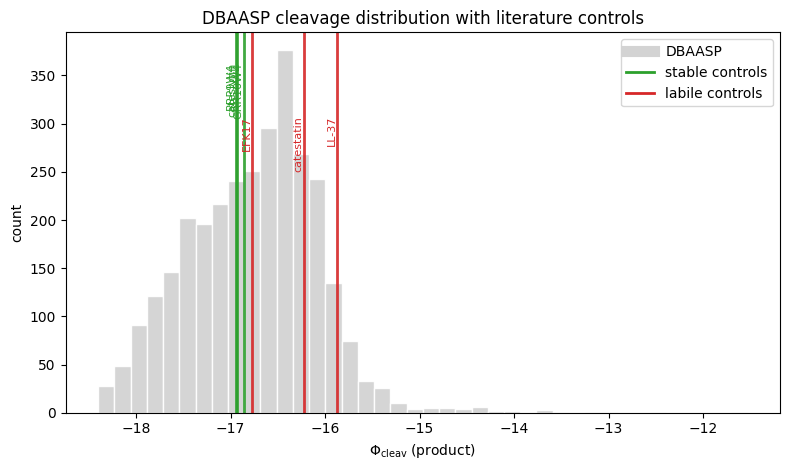

In [10]:
fig, ax = plt.subplots(figsize=(8, 4.8))
ax.hist(
    dbaasp["cleavage"],
    bins=40,
    color="lightgray",
    edgecolor="white",
    alpha=0.95,
    label="DBAASP",
)
colors = {"stable": "#2ca02c", "labile": "#d62728"}
for role, group in controls.groupby("role"):
    for _, row in group.iterrows():
        ax.axvline(
            row["cleavage"],
            color=colors[role],
            lw=2.0,
            alpha=0.9,
        )
        ax.text(
            row["cleavage"],
            ax.get_ylim()[1] * (0.92 if role == "stable" else 0.78),
            row["name"].split()[0],
            rotation=90,
            va="top",
            ha="right",
            fontsize=8,
            color=colors[role],
        )

# Legend proxies
from matplotlib.lines import Line2D

ax.legend(
    handles=[
        Line2D([0], [0], color="lightgray", lw=8, label="DBAASP"),
        Line2D([0], [0], color=colors["stable"], lw=2, label="stable controls"),
        Line2D([0], [0], color=colors["labile"], lw=2, label="labile controls"),
    ]
)
ax.set_xlabel(r"$\Phi_{\mathrm{cleav}}$ (product)")
ax.set_ylabel("count")
ax.set_title("DBAASP cleavage distribution with literature controls")
fig.tight_layout()
fig.savefig(OUT_DIR / "cleavage_controls_on_dbaasp.png", dpi=150)
plt.show()


## Mutation ΔΦ<sub>cleav</sub> heatmaps (controls)

For each literature control, enumerate every single-residue replacement and plot
`ΔΦ_cleav = Φ(mutant) − Φ(parent)` (rows = replacement AA, columns = position).

- **Blue / negative** Δ → mutation lowers cleavage (more stable)
- **Red / positive** Δ → mutation raises cleavage (more labile)
- Black boxes mark the wild-type residue
- Magenta dashed lines mark **literature cleavage bonds** (cut between P1 and P1′)
- Lower panel: wild-type **per-bond contribution** to Φ<sub>cleav</sub> (product rates)

Known cut sites used:
- **LL-37**: aureolysin R19–I20, R23–I24, L31–V32; V8 E16–F17 (AAC 2004)
- **EFK17**: same aureolysin sites mapped into the LL-37 fragment (AAC 2008)
- **catestatin (bCAT)**: L5–S6 (CgA L348–S349); S6–F7 / G13–F14 (strain-dependent; PLOS One 2013)
- **cateslytin / RRP9W4 / GRR10W4**: no reported cleavage sites (resistant)

In [11]:
import importlib
import pep_compass.optimization.components.helpers.proteolysis.cleavage as _mp

importlib.reload(_mp)
from pep_compass.optimization.components.helpers.proteolysis import (
    CleavagePotential,
    MEROPS_AMINO_ACIDS,
)

# Rebuild so this kernel picks up sequence_bond_contributions after code changes.
cleavage = CleavagePotential(panel, variant=VARIANT, device=DEVICE)

AA_LIST = list(MEROPS_AMINO_ACIDS)
AA_IDX = [cleavage.alphabet.index(aa) for aa in AA_LIST]


def mutation_delta_matrix(sequence: str) -> np.ndarray:
    """Return (20 aa x L) matrix of ΔΦ_cleav = Φ(mut) - Φ(parent)."""
    length = len(sequence)
    mutations = {pos: AA_IDX for pos in range(length)}
    scores = cleavage.compute(sequence, mutations)
    mat = np.zeros((len(AA_LIST), length), dtype=np.float64)
    for pos in range(length):
        for aa_i, aa in enumerate(AA_LIST):
            mat[aa_i, pos] = scores[pos][AA_IDX[aa_i]]
    return mat


def plot_control_heatmap(
    sequence: str,
    title: str,
    out_path: Path,
    known_bonds: list | None = None,
    bond_contrib: np.ndarray | None = None,
):
    """Heatmap of position x replacement ΔΦ_cleav, optional cut sites + bond bars.

    known_bonds: list of (bond_index, label) where bond_index is 0-based cut
    between residues bond_index and bond_index+1 (P1 | P1').
    """
    mat = mutation_delta_matrix(sequence)
    length = len(sequence)
    known_bonds = known_bonds or []

    # Diverging scale centered at 0 (negative Δ = more stable).
    vmax = float(np.nanmax(np.abs(mat))) if mat.size else 1.0
    vmax = max(vmax, 1e-6)

    n_panels = 2 if bond_contrib is not None else 1
    fig_h = 4.2 + (2.2 if n_panels == 2 else 0)
    fig, axes = plt.subplots(
        n_panels,
        1,
        figsize=(max(8, 0.35 * length + 3), fig_h),
        gridspec_kw={"height_ratios": [3, 1.2]} if n_panels == 2 else None,
        sharex=True,
    )
    ax = axes[0] if n_panels == 2 else axes

    im = ax.imshow(
        mat,
        aspect="auto",
        cmap="RdBu_r",
        vmin=-vmax,
        vmax=vmax,
        interpolation="nearest",
    )
    ax.set_yticks(range(len(AA_LIST)))
    ax.set_yticklabels(AA_LIST, fontsize=8)
    ax.set_xticks(range(length))
    ax.set_xticklabels(
        [f"{i + 1}\n{aa}" for i, aa in enumerate(sequence)],
        fontsize=7,
    )
    ax.set_ylabel("replacement residue")
    ax.set_title(title)

    # Mark wild-type residue cells.
    for pos, aa in enumerate(sequence):
        if aa in AA_LIST:
            yi = AA_LIST.index(aa)
            ax.add_patch(
                plt.Rectangle(
                    (pos - 0.5, yi - 0.5),
                    1,
                    1,
                    fill=False,
                    edgecolor="black",
                    lw=1.2,
                )
            )

    # Known cleavage bonds: vertical line between P1 and P1'.
    for bond_i, label in known_bonds:
        if 0 <= bond_i < length - 1:
            x = bond_i + 0.5
            ax.axvline(x, color="magenta", lw=1.8, ls="--", alpha=0.95)
            ax.text(
                x,
                -1.3,
                label,
                color="magenta",
                fontsize=7,
                ha="center",
                va="top",
                rotation=0,
                clip_on=False,
            )

    cbar = fig.colorbar(im, ax=ax, fraction=0.02, pad=0.02)
    cbar.set_label(r"$\Delta\Phi_{\mathrm{cleav}}$ (mut - parent)")

    if bond_contrib is not None:
        axb = axes[1]
        xpos = np.arange(len(bond_contrib)) + 0.5
        axb.bar(xpos, bond_contrib, width=0.85, color="steelblue", alpha=0.85)
        for bond_i, label in known_bonds:
            if 0 <= bond_i < len(bond_contrib):
                axb.axvline(bond_i + 0.5, color="magenta", lw=1.5, ls="--")
        axb.set_xlim(-0.5, length - 0.5)
        axb.set_xlabel("bond after residue (P1 | P1')")
        axb.set_ylabel("bond rate" if VARIANT == "product" else "bond score")
        axb.set_title("Per-bond contribution to Phi_cleav (wild-type)")

    fig.tight_layout()
    fig.savefig(out_path, dpi=150, bbox_inches="tight")
    plt.show()
    print("wrote", out_path)

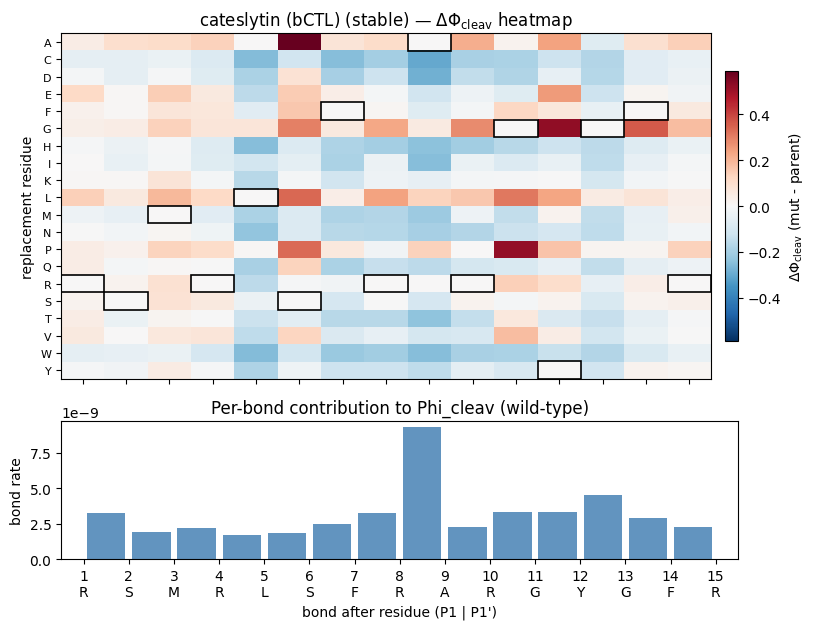

wrote C:\Users\Karol\Desktop\PepCompass\pep-compass\results\clasp_dbaasp_inspection\heatmap_delta_cleavage_cateslytin_bctl.png


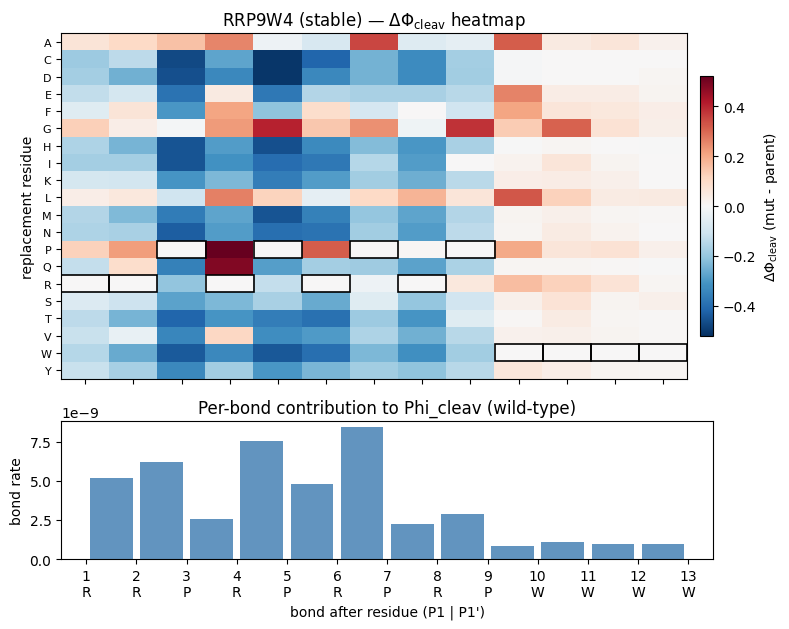

wrote C:\Users\Karol\Desktop\PepCompass\pep-compass\results\clasp_dbaasp_inspection\heatmap_delta_cleavage_rrp9w4.png


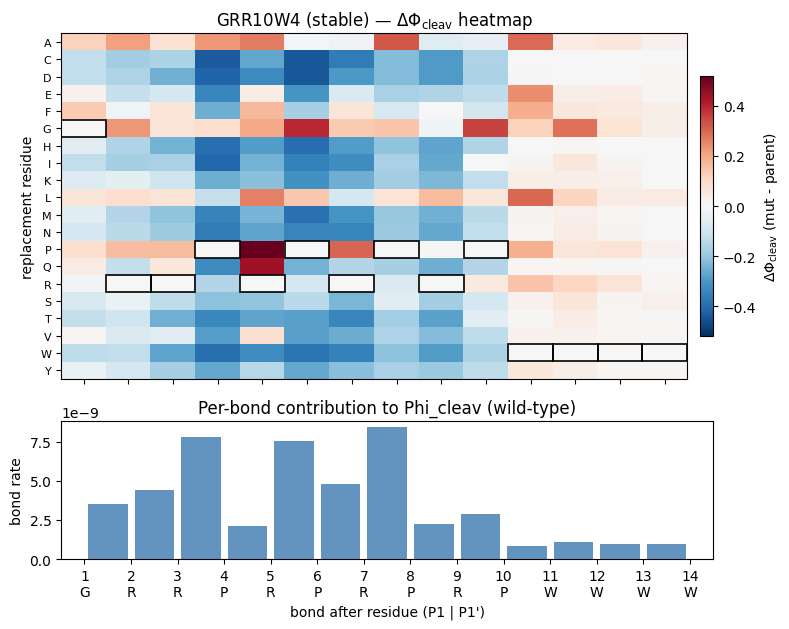

wrote C:\Users\Karol\Desktop\PepCompass\pep-compass\results\clasp_dbaasp_inspection\heatmap_delta_cleavage_grr10w4.png


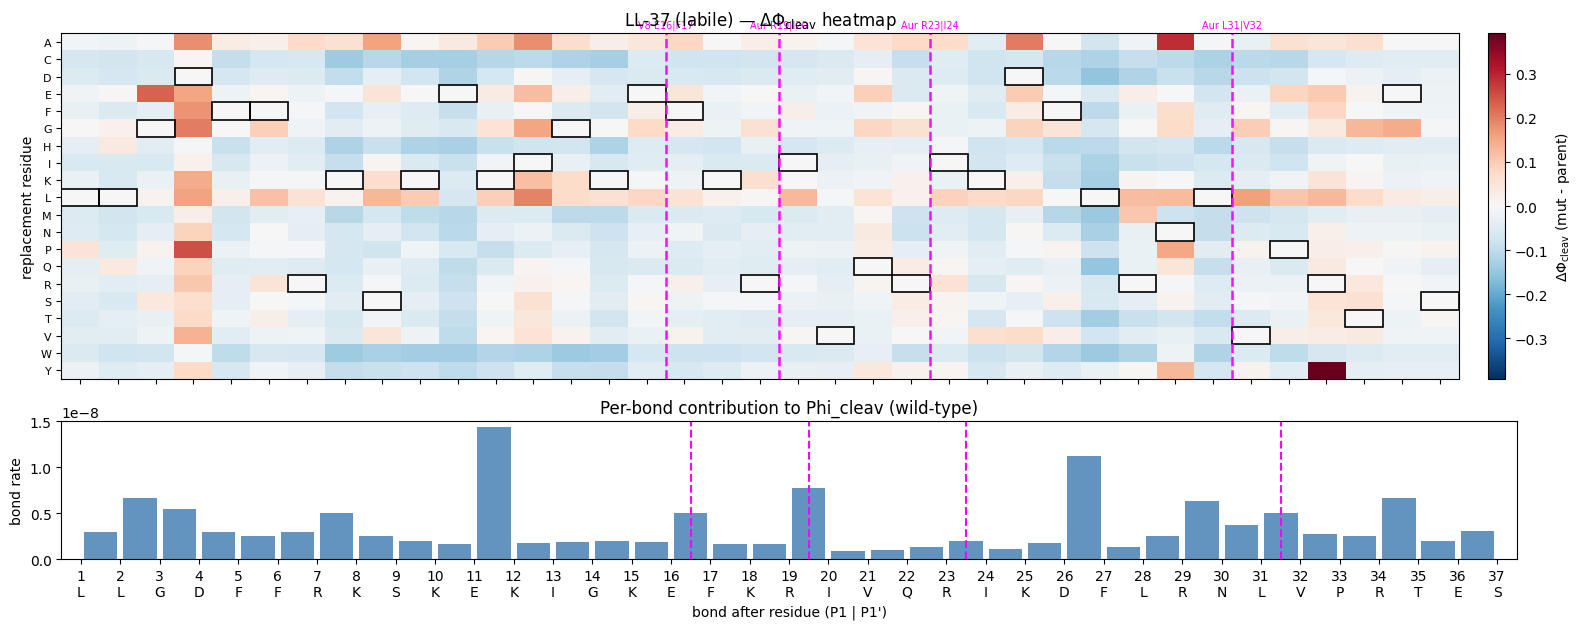

wrote C:\Users\Karol\Desktop\PepCompass\pep-compass\results\clasp_dbaasp_inspection\heatmap_delta_cleavage_ll-37.png


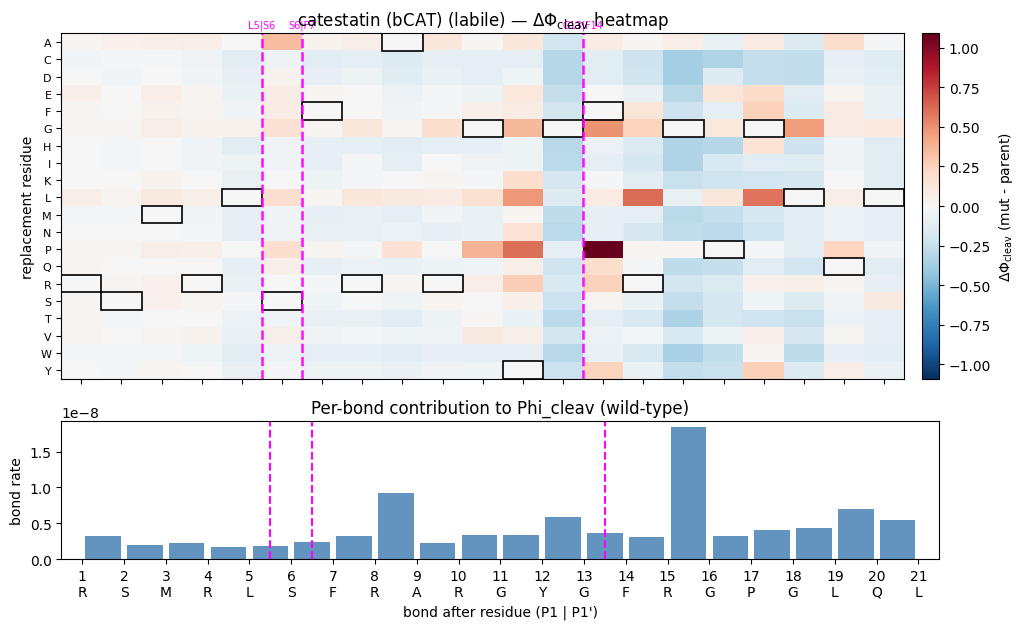

wrote C:\Users\Karol\Desktop\PepCompass\pep-compass\results\clasp_dbaasp_inspection\heatmap_delta_cleavage_catestatin_bcat.png


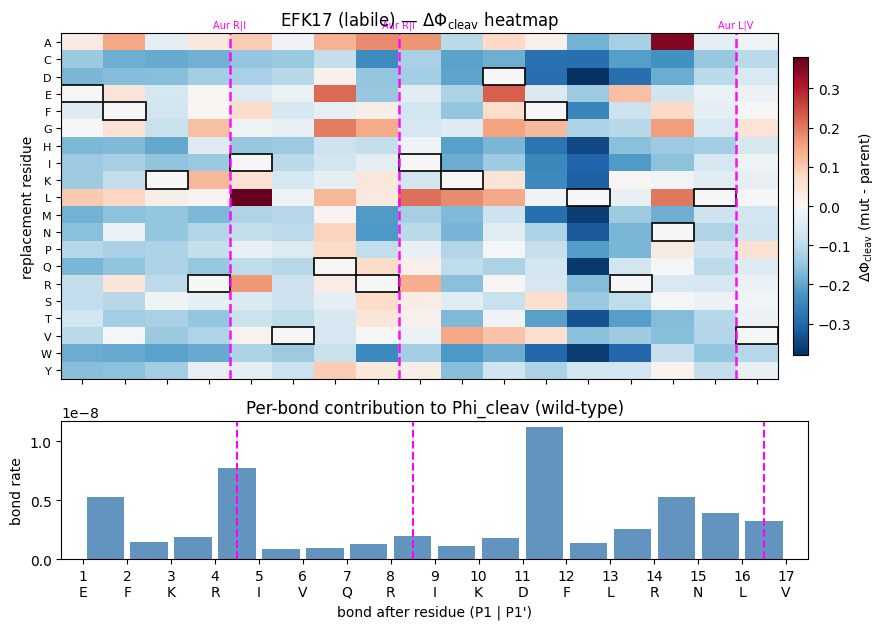

wrote C:\Users\Karol\Desktop\PepCompass\pep-compass\results\clasp_dbaasp_inspection\heatmap_delta_cleavage_efk17.png


In [12]:
# Literature cleavage bonds: 0-based index of the bond after residue i (P1|P1').
KNOWN_CUTS = {
    "LL-37": [
        (15, "V8 E16|F17"),
        (18, "Aur R19|I20"),
        (22, "Aur R23|I24"),
        (30, "Aur L31|V32"),
    ],
    "EFK17": [
        # EFK17 = LL-37[16:33]; map LL-37 bonds into EFK17 coords.
        (3, "Aur R|I"),  # LL-37 19|20 -> EFK17 4|5
        (7, "Aur R|I"),  # LL-37 23|24 -> EFK17 8|9
        (15, "Aur L|V"),  # LL-37 31|32 -> EFK17 16|17
    ],
    "catestatin (bCAT)": [
        (4, "L5|S6"),
        (5, "S6|F7"),
        (12, "G13|F14"),
    ],
}

bond_list = cleavage.sequence_bond_contributions(controls["sequence"].tolist())
controls["bond_contrib"] = bond_list

for _, row in controls.iterrows():
    name = row["name"]
    seq = row["sequence"]
    role = row["role"]
    cuts = KNOWN_CUTS.get(name, [])
    safe = (
        name.lower()
        .replace(" ", "_")
        .replace("(", "")
        .replace(")", "")
        .replace("/", "-")
    )
    out = OUT_DIR / f"heatmap_delta_cleavage_{safe}.png"
    plot_control_heatmap(
        seq,
        title=rf"{name} ({role}) — $\Delta\Phi_{{\mathrm{{cleav}}}}$ heatmap",
        out_path=out,
        known_bonds=cuts,
        bond_contrib=row["bond_contrib"],
    )

## LL-37 vs EFK17 — per-enzyme cleavage (aureolysin / V8) and CLASP score

Inspired by the AAC 2008 proteolysis summary (fraction undegraded after HNE / PE /
Aur / V8): here we score the same two peptides with **individual** MEROPS
enzymes from the *S. aureus* panel (not the weighted mixture).

| MEROPS code | Enzyme |
|---|---|
| `M04.009` | aureolysin (Aur) |
| `S01.269` | glutamyl endopeptidase I (V8 / GluV8) |

Also plot the CLASP objective with λ = 0.1:

`potential = log2_mic(S. aureus) + 0.1 · Φ_cleav(panel)`

Error bars on the CLASP score are the **SD across APEX ensemble models**
(propagated through `log2 MIC`; Φ<sub>cleav</sub> is deterministic for a fixed panel).


In [1]:
import importlib
import math

import pep_compass.optimization.components.helpers.proteolysis.cleavage as _mp
from pep_compass.optimization.components.oracles.strategies.apex_original.predictor import PredictorAPEX
from pep_compass.optimization.components.oracles.strategies.apex_original.utils import onehot_encoding
import torch

importlib.reload(_mp)
from pep_compass.optimization.components.helpers.proteolysis import CleavagePotential

cleavage = CleavagePotential(panel, variant=VARIANT, device=DEVICE)

FOCUS_ENZYMES = {
    "M04.009": "aureolysin (Aur)",
    "S01.269": "V8 / glutamyl endopeptidase I",
}
MIC_COLUMN = "S. aureus ATCC 12600"
LAM = 0.1

pair = controls[controls["name"].isin(["LL-37", "EFK17"])].copy()
rates, codes = cleavage.sequence_protease_rates(pair["sequence"].tolist())
code_to_col = {code: i for i, code in enumerate(codes)}

# --- per-enzyme cleavage ---
rows = []
for pep_i, (_, row) in enumerate(pair.iterrows()):
    for code, label in FOCUS_ENZYMES.items():
        col = code_to_col[code]
        rate = float(rates[pep_i, col])
        rows.append(
            {
                "peptide": row["name"],
                "enzyme_code": code,
                "enzyme": label,
                "rate": rate,
                "log_rate": float(np.log(max(rate, 1e-30))),
            }
        )
enz_df = pd.DataFrame(rows)
enz_path = OUT_DIR / "ll37_efk17_aureolysin_v8_scores.csv"
enz_df.to_csv(enz_path, index=False)
print(enz_df.to_string(index=False))
print("wrote", enz_path)

# --- panel Φ_cleav + APEX ensemble MIC / CLASP potential ---
phi_panel = (
    cleavage.sequence_log_potential(pair["sequence"].tolist())
    .detach()
    .cpu()
    .numpy()
    .astype(float)
)

apex = PredictorAPEX(device=DEVICE, model="full")
mic_idx = apex.pathogen_list.index(MIC_COLUMN)


def apex_ensemble_mic_uM(sequences: list[str]) -> np.ndarray:
    """Return MIC predictions per ensemble model, shape (n_models, n_seq)."""
    data_len = len(sequences)
    per_model = []
    for model in apex.APEX_models:
        model = model.to(apex.device).eval()
        parts = []
        for i in range(int(math.ceil(data_len / float(apex.batch_size)))):
            batch = sequences[i * apex.batch_size : (i + 1) * apex.batch_size]
            x = torch.LongTensor(
                onehot_encoding(batch, apex.max_len, apex.word2idx)
            ).to(apex.device)
            pred = model(x).cpu().detach().numpy()
            parts.append(10 ** (6 - pred))
        per_model.append(np.vstack(parts)[:, mic_idx])
    return np.stack(per_model, axis=0)


mic_ens = apex_ensemble_mic_uM(pair["sequence"].tolist())  # (M, P)
log2_ens = np.log2(np.clip(mic_ens, 1e-12, None))
potential_ens = log2_ens + LAM * phi_panel[np.newaxis, :]

clasp_rows = []
for pep_i, (_, row) in enumerate(pair.iterrows()):
    clasp_rows.append(
        {
            "peptide": row["name"],
            "phi_cleav": float(phi_panel[pep_i]),
            "mic_mean": float(mic_ens[:, pep_i].mean()),
            "mic_sd": float(mic_ens[:, pep_i].std(ddof=1)),
            "log2_mic_mean": float(log2_ens[:, pep_i].mean()),
            "log2_mic_sd": float(log2_ens[:, pep_i].std(ddof=1)),
            "potential_mean": float(potential_ens[:, pep_i].mean()),
            "potential_sd": float(potential_ens[:, pep_i].std(ddof=1)),
            "n_ensemble": int(mic_ens.shape[0]),
            "lambda": LAM,
        }
    )
clasp_df = pd.DataFrame(clasp_rows)
clasp_path = OUT_DIR / "ll37_efk17_clasp_potential_ensemble.csv"
clasp_df.to_csv(clasp_path, index=False)
print("\n", clasp_df.to_string(index=False))
print("wrote", clasp_path)

peptides = ["LL-37", "EFK17"]
enzymes = list(FOCUS_ENZYMES.values())
x = np.arange(len(enzymes))
width = 0.35
colors = {"LL-37": "#d62728", "EFK17": "#1f77b4"}

fig, axes = plt.subplots(1, 3, figsize=(15, 4.6))

# (1) per-enzyme Φ_π
ax = axes[0]
for j, pep in enumerate(peptides):
    vals = [
        float(
            enz_df.loc[
                (enz_df["peptide"] == pep) & (enz_df["enzyme"] == enz), "log_rate"
            ].iloc[0]
        )
        for enz in enzymes
    ]
    ax.bar(x + (j - 0.5) * width, vals, width, label=pep, color=colors[pep])
ax.set_xticks(x)
ax.set_xticklabels(["Aur", "V8"], rotation=0)
ax.set_ylabel(r"$\Phi_\pi = \log R_\pi$")
ax.set_title("Per-enzyme cleavage")
ax.legend(fontsize=8)

# (2) per-enzyme rate
ax = axes[1]
for j, pep in enumerate(peptides):
    vals = [
        float(
            enz_df.loc[
                (enz_df["peptide"] == pep) & (enz_df["enzyme"] == enz), "rate"
            ].iloc[0]
        )
        for enz in enzymes
    ]
    ax.bar(x + (j - 0.5) * width, vals, width, label=pep, color=colors[pep])
ax.set_xticks(x)
ax.set_xticklabels(["Aur", "V8"], rotation=0)
ax.set_ylabel(r"$R_\pi$")
ax.set_yscale("log")
ax.set_title("Per-enzyme rate")
ax.legend(fontsize=8)

# (3) CLASP potential with APEX ensemble SD
ax = axes[2]
xp = np.arange(len(peptides))
means = [
    float(clasp_df.loc[clasp_df["peptide"] == pep, "potential_mean"].iloc[0])
    for pep in peptides
]
sds = [
    float(clasp_df.loc[clasp_df["peptide"] == pep, "potential_sd"].iloc[0])
    for pep in peptides
]
ax.bar(
    xp,
    means,
    yerr=sds,
    color=[colors[p] for p in peptides],
    capsize=5,
    width=0.55,
    error_kw={"elinewidth": 1.5, "capthick": 1.5},
)
ax.set_xticks(xp)
ax.set_xticklabels(peptides)
ax.set_ylabel(r"$\log_2\mathrm{MIC} + 0.1\,\Phi_{\mathrm{cleav}}$")
ax.set_title(f"CLASP potential (λ={LAM})\nerror = APEX ensemble SD")

fig.suptitle("LL-37 vs EFK17 — Aur/V8 cleavage and CLASP score", y=1.03)
fig.tight_layout()
fig.savefig(
    OUT_DIR / "ll37_efk17_aureolysin_v8_and_clasp.png",
    dpi=150,
    bbox_inches="tight",
)
plt.show()

NameError: name 'panel' is not defined